In [ ]:
!pip install mtcnn keras-facenet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.4 MB/s eta 0:00:00
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=6107079ae168e07529a313a5644c01355deaffb0cf479cd6bb38f1b2601dab18
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras-facenet


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from mtcnn import MTCNN
from keras_facenet import FaceNet
from google.colab import files

In [ ]:
detector = MTCNN()
embedder = FaceNet()

In [ ]:
def extract_face(img):
    faces = detector.detect_faces(img)

    if len(faces) == 0:
        return None

    x, y, w, h = faces[0]['box']
    face = img[y:y+h, x:x+w]
    face = cv2.resize(face, (160,160))

    return face

In [ ]:
def get_embedding(face):
    face = face.astype('float32')
    face = np.expand_dims(face, axis=0)
    embedding = embedder.embeddings(face)
    return embedding[0]

In [ ]:
known_faces = {}
known_names = []

print("Upload known person images")
uploaded = files.upload()

for fn in uploaded.keys():
    img = cv2.imread(fn)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    face = extract_face(img)

    if face is not None:
        embedding = get_embedding(face)

        name = fn.split('.')[0]  # filename = person name
        known_faces[name] = embedding
        known_names.append(name)

print("Known faces stored:", known_names)

Upload known person images


Saving istockphoto-1346125184-612x612.jpg to istockphoto-1346125184-612x612.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Known faces stored: ['istockphoto-1346125184-612x612']


Upload test image


Saving istockphoto-1346125184-612x612.jpg to istockphoto-1346125184-612x612 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


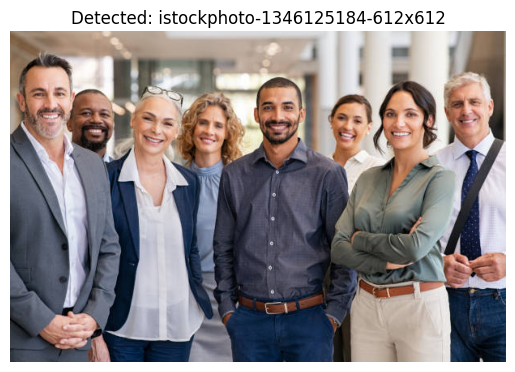

Person: istockphoto-1346125184-612x612


In [ ]:
print("Upload test image")
uploaded = files.upload()

for fn in uploaded.keys():
    img = cv2.imread(fn)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    face = extract_face(img)

    if face is None:
        print("No face detected")
        continue

    embedding = get_embedding(face)

    # Compare with known faces
    min_dist = float('inf')
    identity = "Unknown"

    for name, known_embedding in known_faces.items():
        dist = np.linalg.norm(known_embedding - embedding)

        if dist < min_dist:
            min_dist = dist
            identity = name

    # Threshold (important)
    if min_dist > 0.9:
        identity = "Unknown"

    plt.imshow(img)
    plt.title(f"Detected: {identity}")
    plt.axis('off')
    plt.show()

    print("Person:", identity)